#Set-up

In [ ]:
# --- CONFIG ---
REPO_URL = "https://github.com/Yogesh-SN/cobrapy-learning.git"
REPO_NAME = "cobrapy-learning"
BRANCH = "main"

# --- SETUP ---
import os
import sys

if os.path.exists(REPO_NAME):
    print("Repo exists → pulling latest changes...")
    %cd cobrapy-learning
    !git fetch origin
    !git reset --hard origin/main
    !git clean -fd
else:
    print("Cloning fresh repo...")
    !git clone {REPO_URL}
    %cd cobrapy-learning

# --- INSTALL DEPENDENCIES ---
if os.path.exists("requirements.txt"):
    !pip install -r requirements.txt

# --- FIX IMPORT PATH ---
SRC_PATH = os.path.abspath("src")
if SRC_PATH not in sys.path:
    sys.path.append(SRC_PATH)

print("Setup complete. Current dir:", os.getcwd())

In [ ]:
!git log -1
!ls src
import helpers
print(helpers.__file__)

In [57]:
import importlib
import helpers

importlib.reload(helpers)

<module 'helpers' from '/content/cobrapy-learning/src/helpers.py'>

In [58]:
from helpers import load_model, flux_sampling, biomass_reaction

In [59]:
model = load_model('models/e_coli_core.xml')

In [60]:
s = flux_sampling(model,100) #By default, set to optgp

print(s['BIOMASS_Ecoli_core_w_GAM'].max())
print(f'{model.slim_optimize()} is the FBA Value')

0.21442931545667
0.8739215069684295 is the FBA Value


In [61]:
print(f'There are {len([reaction for reaction in model.reactions])} reactions in this model, and therefore these many columns in the sampling')

There are 95 reactions in this model, and therefore these many columns in the sampling


In [62]:
biomass_reaction(model)

Reaction identifier,BIOMASS_Ecoli_core_w_GAM
Name,Biomass Objective Function with GAM
Memory address,0x7e080dd6cbc0
Stoichiometry,1.496 3pg_c + 3.7478 accoa_c + 59.81 atp_c + 0.361 e4p_c + 0.0709 f6p_c + 0.129 g3p_c + 0.205 g6p_c + 0.2557 gln__L_c + 4.9414 glu__L_c + 59.81 h2o_c + 3.547 nad_c + 13.0279 nadph_c + 1.7867 oaa_c... 1.496 3-Phospho-D-glycerate + 3.7478 Acetyl-CoA + 59.81 ATP C10H12N5O13P3 + 0.361 D-Erythrose 4-phosphate + 0.0709 D-Fructose 6-phosphate + 0.129 Glyceraldehyde 3-phosphate + 0.205 D-Glucose...
GPR,
Lower bound,0.0
Upper bound,1000.0


#Flux values as given by Flux Sampling using optgp & Pair-Plot for a few key reactions

In [63]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

samples = flux_sampling(model, 1000) #SAMPLING

reactions = ["EX_glc__D_e", "EX_o2_e", "BIOMASS_Ecoli_core_w_GAM", "ATPM", "PFK"]

df = samples[reactions]

solution = model.optimize()
objective_fluxes = solution.fluxes

In [71]:
samples.head()

,PFK,PFL,PGI,PGK,PGL,ACALD,AKGt2r,PGM,PIt2r,ALCD2x,...,MALS,MALt2_2,MDH,ME1,ME2,NADH16,NADTRHD,NH4t,O2t,PDH
0,8.383884,0.987757,2.939729,-17.441081,6.945362,-0.162505,-0.664832,-17.431780,0.022873,-0.160050,...,4.760634,0.0,-9.495248,7.399432,15.539141,74.384462,42.108053,0.145520,41.533577,18.841312
1,12.973885,2.300915,7.856702,-18.990082,2.054076,-0.889464,-0.179867,-18.892415,0.240166,-0.871302,...,6.540640,0.0,2.342756,3.552810,15.048887,78.722185,48.592852,1.248261,46.562999,21.243737
2,6.748401,0.114573,0.340225,-16.578735,9.544647,-3.635249,-0.750835,-16.572440,0.015478,-1.534759,...,4.559201,0.0,-10.161377,5.283432,17.466954,70.737895,48.529178,0.411167,39.383852,19.271358
3,11.271783,4.841632,1.264982,-15.656118,7.896357,-4.577015,-0.399855,-15.633202,0.056353,-2.552258,...,3.208829,0.0,-4.545087,8.202946,4.256545,48.344989,25.531517,0.677779,26.525282,10.967316
4,14.457834,8.265858,-2.397795,-15.453664,12.324965,-1.795345,-0.063841,-15.259134,0.478353,-0.835153,...,6.090717,0.0,5.201800,2.913870,7.339515,67.815113,46.142132,1.055645,38.589791,10.458056


In [64]:
means = df.mean()
print(means,'\n')
variances = df.var()
print(variances)

EX_glc__D_e                 -9.589741
EX_o2_e                    -33.581368
BIOMASS_Ecoli_core_w_GAM     0.039276
ATPM                        16.736655
PFK                         15.817517
dtype: float64 

EX_glc__D_e                  0.157848
EX_o2_e                     34.757589
BIOMASS_Ecoli_core_w_GAM     0.001430
ATPM                        58.528454
PFK                         67.328072
dtype: float64


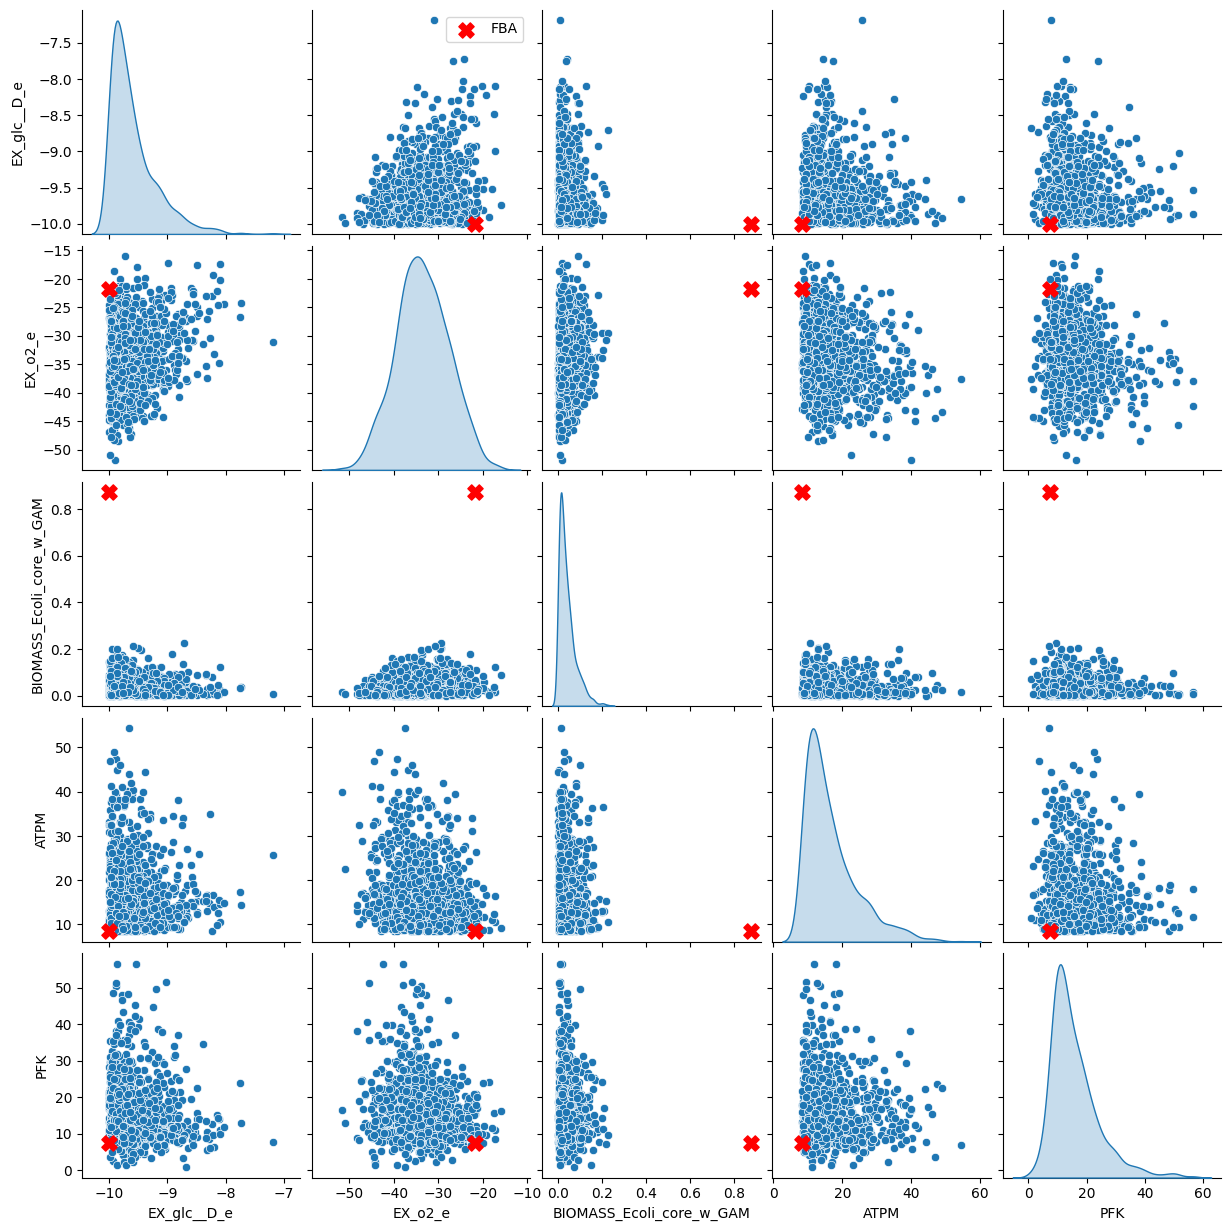

In [65]:
g = sns.pairplot(df, diag_kind="kde")
fba_point = objective_fluxes[reactions]

# Loop over axes
for i, rxn_y in enumerate(reactions):
    for j, rxn_x in enumerate(reactions):
        if i != j:  # skip diagonal
            ax = g.axes[i, j]

            x_val = fba_point[rxn_x]
            y_val = fba_point[rxn_y]

            ax.scatter(x_val, y_val, color='red', marker='X', s=120, label='FBA')

g.axes[0, 1].legend()

#**Observation and Interpretation**

---


The red “X” markers represent the FBA (Flux Balance Analysis) solution overlaid on the flux sampling pair plot. A clear pattern emerges: for most reactions (except the biomass objective itself), the FBA point lies at the **edges or corners of the sampled flux distributions**.

This is not incidental - it reflects a fundamental property of FBA. Flux sampling explores the entire **feasible solution space** defined by stoichiometric and thermodynamic constraints, producing a cloud of possible metabolic states. In contrast, FBA solves a **linear optimization problem** (typically maximizing biomass), and such problems achieve their optimum at **extreme points (vertices)** of the feasible region.

As a result, the FBA solution appears at the **boundary of the flux space**, which manifests visually as being located at the corners or edges of the clusters in the pair plot. These edge positions correspond to **maximal or minimal allowable flux configurations** required to optimize the objective.

The biomass reaction behaves slightly differently because it is the **objective being maximized**. Its FBA value naturally sits at the upper extreme of its own distribution, rather than forming a “corner” relationship in pairwise comparisons.

Overall, this visualization highlights the distinction between:

* **Flux sampling** → captures the full range of feasible metabolic behaviors
* **FBA** → selects a single, optimal (and often extreme) metabolic state

This reinforces the idea that FBA solutions represent **optimal but not necessarily typical** states within the metabolic network.


#Individual Kernel density estimation (KDE) graphs

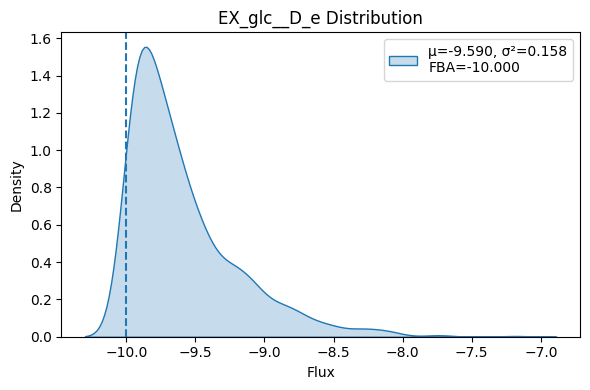

In [66]:
rxn = "EX_glc__D_e"

plt.figure(figsize=(6, 4))
sns.kdeplot(df[rxn], fill=True)

obj_val = objective_fluxes[rxn]
plt.axvline(obj_val, linestyle='--')

plt.title(f"{rxn} Distribution")
plt.xlabel("Flux")
plt.ylabel("Density")

plt.legend([f"μ={means[rxn]:.3f}, σ²={variances[rxn]:.3f}\nFBA={obj_val:.3f}"])

plt.tight_layout()
plt.show()

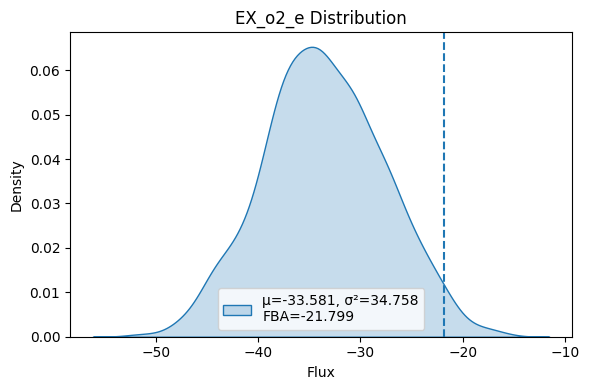

In [67]:
rxn = "EX_o2_e"

plt.figure(figsize=(6, 4))
sns.kdeplot(df[rxn], fill=True)

obj_val = objective_fluxes[rxn]
plt.axvline(obj_val, linestyle='--')

plt.title(f"{rxn} Distribution")
plt.xlabel("Flux")
plt.ylabel("Density")

plt.legend([f"μ={means[rxn]:.3f}, σ²={variances[rxn]:.3f}\nFBA={obj_val:.3f}"])

plt.tight_layout()
plt.show()

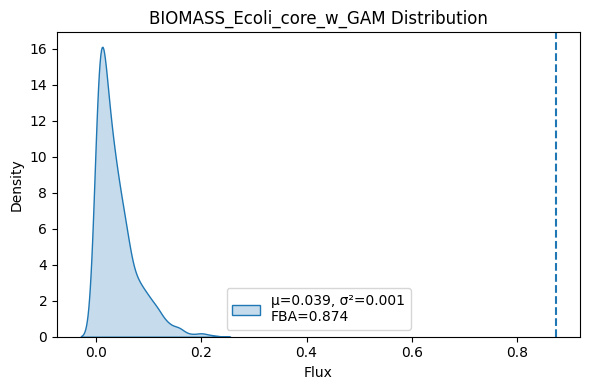

In [68]:
rxn = "BIOMASS_Ecoli_core_w_GAM"

plt.figure(figsize=(6, 4))
sns.kdeplot(df[rxn], fill=True)

obj_val = objective_fluxes[rxn]
plt.axvline(obj_val, linestyle='--')

plt.title(f"{rxn} Distribution")
plt.xlabel("Flux")
plt.ylabel("Density")

plt.legend([f"μ={means[rxn]:.3f}, σ²={variances[rxn]:.3f}\nFBA={obj_val:.3f}"])

plt.tight_layout()
plt.show()

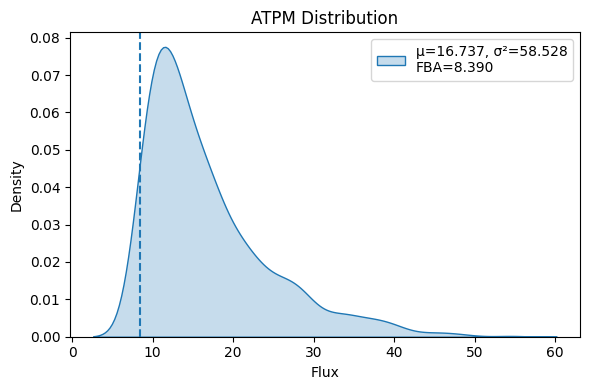

In [69]:
rxn = "ATPM"

plt.figure(figsize=(6, 4))
sns.kdeplot(df[rxn], fill=True)

obj_val = objective_fluxes[rxn]
plt.axvline(obj_val, linestyle='--')

plt.title(f"{rxn} Distribution")
plt.xlabel("Flux")
plt.ylabel("Density")

plt.legend([f"μ={means[rxn]:.3f}, σ²={variances[rxn]:.3f}\nFBA={obj_val:.3f}"])

plt.tight_layout()
plt.show()

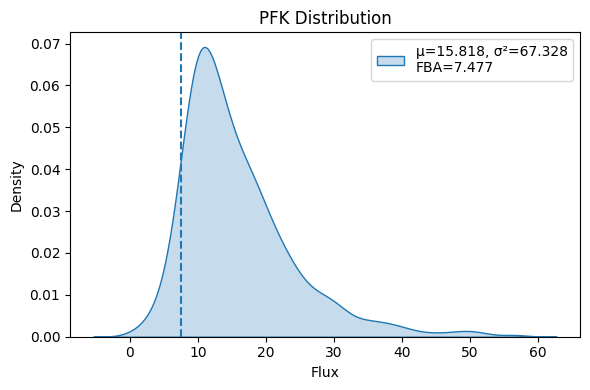

In [70]:
rxn = "PFK"

plt.figure(figsize=(6, 4))
sns.kdeplot(df[rxn], fill=True)

obj_val = objective_fluxes[rxn]
plt.axvline(obj_val, linestyle='--')

plt.title(f"{rxn} Distribution")
plt.xlabel("Flux")
plt.ylabel("Density")

plt.legend([f"μ={means[rxn]:.3f}, σ²={variances[rxn]:.3f}\nFBA={obj_val:.3f}"])

plt.tight_layout()
plt.show()